# 🧹 Data Preprocessing Guide — Part 2 (Advanced & Practical Topics)

**A follow-up to the main "Complete Data Preprocessing Guide" notebook.**

Part 1 covered the core cleaning pipeline: missing values, outliers, scaling, and encoding.
That's enough to get a first model running. This notebook covers the things you'll run into
almost immediately *after* that — the topics that separate "it runs" from "it's actually reliable."

Same format as before: **Theory → When to use it → Runnable code → Pitfalls**.

---

## 📚 Table of Contents

1. [Fixing Data Types & Handling Duplicates](#1)
2. [Feature Engineering](#2)
3. [Feature Selection & Multicollinearity](#3)
4. [Handling Imbalanced Data](#4)
5. [Train/Test Splits & Cross-Validation Done Right](#5)
6. [Saving a Pipeline for Production](#6)
7. [Checklist & Pitfalls (Part 2)](#7)
8. [Practice Exercises (Part 2)](#8)

---


In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn statsmodels joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


<a id="1"></a>
## 1. Fixing Data Types & Handling Duplicates

### 1.1 Theory — why this matters

Real-world data almost never arrives with clean types. A date might be stored as the text
`"2024-01-05"`, a number might be stored as `"1,200"` (with a comma, so pandas reads it as text),
and a category like `low/medium/high` might be sitting in a generic `object` column.

**Wrong dtypes silently break things** — you can't compute a mean on a numeric-looking string
column, you can't extract a month from a date stored as text, and models will either error out or
(worse) silently treat a number as a category.

### 1.2 Detecting dtype problems


In [2]:
# A deliberately messy example dataset - very common shape in real exports (CSV from Excel, forms, etc.)
messy = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5, 5],                       # note the duplicate id at the end
    "signup_date": ["2023-01-05", "2023-02-14", "2023/03/20", "2023-04-01", "2023-05-19", "2023-05-19"],
    "monthly_spend": ["1,200", "950.50", "2,300", "800", "1,100", "1,100"],   # numbers stored as text
    "plan": ["basic", "PREMIUM", "Basic ", "premium", "basic", "basic"],      # inconsistent casing/spacing
})
messy


,customer_id,signup_date,monthly_spend,plan
0,1,2023-01-05,"1,200",basic
1,2,2023-02-14,950.50,PREMIUM
2,3,2023/03/20,"2,300",Basic
3,4,2023-04-01,800,premium
4,5,2023-05-19,"1,100",basic
5,5,2023-05-19,"1,100",basic


In [3]:
messy.dtypes


customer_id      int64
signup_date        str
monthly_spend      str
plan               str
dtype: object

Notice: `signup_date` and `monthly_spend` are both `object` (text) even though they're
clearly a date and a number. `plan` has inconsistent casing/whitespace that will be treated as
4 different categories by a naive encoder, when it should really be 2.

### 1.3 Fixing each type


In [4]:
clean = messy.copy()

# 1. Fix the numeric column: strip commas, then convert to float
clean["monthly_spend"] = clean["monthly_spend"].str.replace(",", "", regex=False).astype(float)

# 2. Fix the date column: pandas can parse mixed formats with errors='coerce' turning
#    anything unparseable into NaT (Not a Time) instead of crashing
clean["signup_date"] = pd.to_datetime(clean["signup_date"], format="mixed", errors="coerce")

# 3. Fix the categorical column: standardize casing and strip whitespace BEFORE encoding
clean["plan"] = clean["plan"].str.strip().str.lower()

clean.dtypes


customer_id               int64
signup_date      datetime64[us]
monthly_spend           float64
plan                        str
dtype: object

In [5]:
clean


,customer_id,signup_date,monthly_spend,plan
0,1,2023-01-05,1200.0,basic
1,2,2023-02-14,950.5,premium
2,3,2023-03-20,2300.0,basic
3,4,2023-04-01,800.0,premium
4,5,2023-05-19,1100.0,basic
5,5,2023-05-19,1100.0,basic


### 1.4 Handling Duplicates

There are two different questions to ask:

1. **Are there exact duplicate rows?** (`df.duplicated()`) — every single column matches another row
2. **Are there duplicate *entities* with different values?** (`df.duplicated(subset=[...])`) — e.g. the
   same `customer_id` appearing twice, possibly with slightly different data (a more common and more
   dangerous real-world problem)

⚠️ **The important decision isn't "how do I remove duplicates" (that's one line of code) — it's
"what actually counts as a duplicate for this dataset?"** Two rows with the same `customer_id` but a
different `signup_date` might be a genuine repeat customer, not a data error. Always check *why*
before deleting.


In [6]:
# 1. Exact duplicate rows (every column identical)
print("Fully duplicated rows:", clean.duplicated().sum())

# 2. Duplicate on a business key (customer_id) - this is usually the more meaningful check
print("Duplicate customer_id rows:", clean.duplicated(subset=["customer_id"]).sum())

# Inspect them before deciding what to do
clean[clean.duplicated(subset=["customer_id"], keep=False)]


Fully duplicated rows: 1
Duplicate customer_id rows: 1


,customer_id,signup_date,monthly_spend,plan
4,5,2023-05-19,1100.0,basic
5,5,2023-05-19,1100.0,basic


In [7]:
# Here the duplicate customer_id rows are also fully identical - safe to drop, keeping the first occurrence
clean_deduped = clean.drop_duplicates(subset=["customer_id"], keep="first")
print("Shape before:", clean.shape, " Shape after:", clean_deduped.shape)
clean_deduped


Shape before: (6, 4)  Shape after: (5, 4)


,customer_id,signup_date,monthly_spend,plan
0,1,2023-01-05,1200.0,basic
1,2,2023-02-14,950.5,premium
2,3,2023-03-20,2300.0,basic
3,4,2023-04-01,800.0,premium
4,5,2023-05-19,1100.0,basic


### 1.5 Quick-reference

| Problem | Fix |
|---|---|
| Number stored as text (with commas/currency symbols) | `.str.replace(",", "").astype(float)` |
| Date stored as text | `pd.to_datetime(col, errors="coerce")` |
| Inconsistent text casing/whitespace in categories | `.str.strip().str.lower()` **before** encoding |
| Exact duplicate rows | `df.drop_duplicates()` |
| Duplicate business key (e.g. customer/order ID) | `df.drop_duplicates(subset=[...], keep="first"/"last")` — but inspect first! |


<a id="2"></a>
## 2. Feature Engineering

### 2.1 Theory — why this matters

**Feature engineering** is creating *new*, more useful columns out of the ones you already have.
This is arguably as important as cleaning — a well-engineered feature can improve a model far more
than switching from one algorithm to another. Cleaning removes noise; feature engineering adds signal.

### 2.2 Extracting features from dates

A raw date column is not directly useful to most models — but the parts of it usually are.


In [8]:
dates_df = pd.DataFrame({
    "order_date": pd.to_datetime(["2024-01-05", "2024-06-15", "2024-11-29", "2024-12-25"])
})

dates_df["year"] = dates_df["order_date"].dt.year
dates_df["month"] = dates_df["order_date"].dt.month
dates_df["day_of_week"] = dates_df["order_date"].dt.dayofweek   # 0=Monday
dates_df["is_weekend"] = dates_df["day_of_week"].isin([5, 6]).astype(int)
dates_df["quarter"] = dates_df["order_date"].dt.quarter

dates_df


,order_date,year,month,day_of_week,is_weekend,quarter
0,2024-01-05,2024,1,4,0,1
1,2024-06-15,2024,6,5,1,2
2,2024-11-29,2024,11,4,0,4
3,2024-12-25,2024,12,2,0,4


### 2.3 Binning / Discretization

Turning a continuous number into meaningful groups. Useful when a model benefits from a simpler
signal (e.g. "age group" instead of exact age), or to make a skewed numeric column easier to interpret.


In [9]:
ages = pd.DataFrame({"age": [5, 17, 22, 35, 45, 60, 72, 90]})

# Equal-width bins with custom labels
ages["age_group"] = pd.cut(
    ages["age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["child", "teen", "young_adult", "adult", "senior"]
)

# Equal-frequency bins (quantile-based) - useful when you want each bin to have a similar row count
ages["age_quartile"] = pd.qcut(ages["age"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

ages


,age,age_group,age_quartile
0,5,child,Q1
1,17,teen,Q1
2,22,young_adult,Q2
3,35,young_adult,Q2
4,45,adult,Q3
5,60,adult,Q3
6,72,senior,Q4
7,90,senior,Q4


### 2.4 Ratios & Interaction Features

Sometimes the *relationship* between two columns is more predictive than either column alone.


In [10]:
houses = pd.DataFrame({
    "price": [200000, 350000, 500000],
    "area_sqft": [1000, 1500, 2000],
    "bedrooms": [2, 3, 4],
})

houses["price_per_sqft"] = houses["price"] / houses["area_sqft"]        # a ratio feature
houses["rooms_per_1000_sqft"] = houses["bedrooms"] / (houses["area_sqft"] / 1000)  # interaction feature

houses


,price,area_sqft,bedrooms,price_per_sqft,rooms_per_1000_sqft
0,200000,1000,2,200.000000,2.0
1,350000,1500,3,233.333333,2.0
2,500000,2000,4,250.000000,2.0


### 2.5 Aggregation features (grouping)

When you have repeated entities (e.g. multiple transactions per customer), aggregating them into
per-entity features is one of the highest-value feature engineering moves in real business data.


In [11]:
transactions = pd.DataFrame({
    "customer_id": [1, 1, 1, 2, 2, 3],
    "amount": [50, 120, 30, 400, 90, 15],
})

customer_features = transactions.groupby("customer_id")["amount"].agg(
    total_spend="sum",
    avg_spend="mean",
    num_transactions="count",
    max_spend="max",
).reset_index()

customer_features


,customer_id,total_spend,avg_spend,num_transactions,max_spend
0,1,200,66.666667,3,120
1,2,490,245.000000,2,400
2,3,15,15.000000,1,15


### 2.6 Quick-reference

| Raw data | Engineered feature idea |
|---|---|
| Date/timestamp | year, month, day-of-week, is_weekend, quarter, days-since-event |
| Continuous number | binned groups (`pd.cut`/`pd.qcut`), log/sqrt transform (Part 1, Section 6) |
| Two related numeric columns | ratio, difference, product (interaction feature) |
| Repeated rows per entity (customer, product) | groupby aggregations: sum, mean, count, min/max |
| Free text | length, word count, presence of keywords (basic NLP features) |

⚠️ **Pitfall:** feature engineering must respect the train/test split too — if an aggregation (like
`avg_spend`) is computed using the *whole* dataset including test rows, that's data leakage. Compute
aggregations from training data only, then apply/join them onto the test set.


<a id="3"></a>
## 3. Feature Selection & Multicollinearity

### 3.1 Theory — why this matters

More features isn't always better. Irrelevant or redundant features can hurt model performance,
slow down training, and make models harder to interpret. **Multicollinearity** (two or more features
being highly correlated with each other) is especially a problem for linear models — it makes
coefficients unstable and hard to interpret, though it usually doesn't hurt tree-based models' accuracy.

### 3.2 Correlation heatmap — the first thing to check


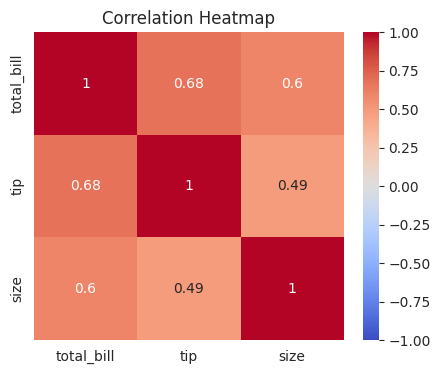

In [12]:
tips = sns.load_dataset("tips")
numeric_tips = tips.select_dtypes(include=[np.number])

plt.figure(figsize=(5, 4))
sns.heatmap(numeric_tips.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


### 3.3 Variance Inflation Factor (VIF)

VIF quantifies multicollinearity precisely. As a rule of thumb:
- **VIF < 5**: fine
- **VIF 5–10**: moderate, worth watching
- **VIF > 10**: strong multicollinearity, consider dropping/combining one of the correlated features


In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = numeric_tips.drop(columns=["tip"]).assign(const=1)   # VIF calculation needs a constant term
vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif_data[vif_data["feature"] != "const"]


,feature,VIF
0,total_bill,1.557586
1,size,1.557586


### 3.4 Removing low-variance features

A feature that barely changes across rows (e.g. a column that's 99% the same value) carries almost
no information and can usually be dropped.


In [14]:
from sklearn.feature_selection import VarianceThreshold

low_var_example = pd.DataFrame({
    "useful_feature": [1, 5, 3, 8, 2, 9, 4],
    "almost_constant": [1, 1, 1, 1, 1, 1, 2],   # barely varies - low information
})

selector = VarianceThreshold(threshold=0.1)
selected = selector.fit_transform(low_var_example)
kept_columns = low_var_example.columns[selector.get_support()]

print("Columns kept:", list(kept_columns))


Columns kept: ['useful_feature', 'almost_constant']


### 3.5 Dimensionality reduction — PCA (brief)

When you have many correlated numeric features, **Principal Component Analysis (PCA)** compresses
them into fewer new "components" that capture most of the original variance. Useful for visualization
and for some models, but the new components are no longer directly interpretable as your original
features — a trade-off to keep in mind.


In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(numeric_tips.drop(columns=["tip"]))

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

print("Variance explained by each component:", pca.explained_variance_ratio_.round(3))
print("Total variance captured by 2 components:", round(pca.explained_variance_ratio_.sum(), 3))


Variance explained by each component: [0.799 0.201]
Total variance captured by 2 components: 1.0


### 3.6 Quick-reference

| Situation | Technique |
|---|---|
| Want a quick visual scan for redundant numeric features | Correlation heatmap |
| Need to quantify multicollinearity precisely | VIF |
| A feature barely varies across rows | `VarianceThreshold` |
| Too many correlated numeric features, need fewer dimensions | PCA |
| Using a linear model and worried about instability | Drop one of each highly-correlated pair, or use Ridge/Lasso regularization |
| Using a tree-based model | Multicollinearity matters far less — usually safe to leave as-is |


<a id="4"></a>
## 4. Handling Imbalanced Data

### 4.1 Theory — why this matters

A dataset is **imbalanced** when one class massively outnumbers another — e.g. 95% "not fraud" vs
5% "fraud". This is extremely common in real classification problems (fraud detection, churn,
disease diagnosis, defect detection).

**Why it's dangerous:** a model can get 95% accuracy by simply always predicting "not fraud" — and
be completely useless. This is why imbalance must be addressed both in **how you preprocess the
data** and **how you evaluate the model**.


In [16]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=5, weights=[0.95, 0.05], random_state=42
)
print("Class distribution:")
print(pd.Series(y).value_counts())
print("\nClass 1 (minority) makes up:", round((y == 1).mean() * 100, 1), "% of the data")


Class distribution:
0    944
1     56
Name: count, dtype: int64

Class 1 (minority) makes up: 5.6 % of the data


### 4.2 Detecting imbalance

Always check `value_counts()` (or `.value_counts(normalize=True)` for percentages) on your target
column *before* modeling — this single check prevents the "95% accuracy, useless model" trap.

### 4.3 Fixing it — three main approaches


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify keeps the same class ratio in both splits
)
print("Train class distribution:\n", pd.Series(y_train).value_counts())


Train class distribution:
 0    755
1     45
Name: count, dtype: int64


**Approach 1 — Oversampling the minority class with SMOTE** (Synthetic Minority Oversampling
Technique): instead of just duplicating minority rows, SMOTE generates new synthetic examples
similar to existing minority-class points.

⚠️ **Critical rule: only apply SMOTE to the training set, never to the test set.** The test set must
reflect the real, original class distribution — otherwise your evaluation is meaningless.


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", pd.Series(y_train).value_counts())
print("\nAfter SMOTE (train set only):\n", pd.Series(y_train_resampled).value_counts())


Before SMOTE:
 0    755
1     45
Name: count, dtype: int64

After SMOTE (train set only):
 0    755
1    755
Name: count, dtype: int64


**Approach 2 — Undersampling the majority class**: randomly remove rows from the majority
class instead of creating new minority rows. Simple, but throws away data.


In [19]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print("After undersampling (train set only):\n", pd.Series(y_train_under).value_counts())


After undersampling (train set only):
 0    45
1    45
Name: count, dtype: int64


**Approach 3 — Class weighting**: instead of changing the data at all, tell the model to
*penalize mistakes on the minority class more heavily*. Often the simplest and safest option — no
synthetic data, no thrown-away rows.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# class_weight="balanced" automatically weights classes inversely proportional to their frequency
model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.88      0.93       189
           1       0.27      0.73      0.39        11

    accuracy                           0.88       200
   macro avg       0.62      0.81      0.66       200
weighted avg       0.94      0.88      0.90       200



### 4.4 Just as important: use the right evaluation metric

On imbalanced data, **accuracy is misleading**. Use:

- **Precision** — of everything predicted positive, how much was actually positive?
- **Recall** — of everything actually positive, how much did we catch?
- **F1-score** — balance of precision and recall
- **ROC-AUC / PR-AUC** — overall ranking quality across thresholds

The `classification_report` above already gives you precision/recall/F1 per class — always look at
those instead of a single accuracy number when classes are imbalanced.

### 4.5 Quick-reference

| Situation | Recommended approach |
|---|---|
| Moderate imbalance (e.g. 70/30), simple model | `class_weight="balanced"` — try this first |
| Severe imbalance (e.g. 95/5+), need more minority signal | SMOTE (oversample) on training data only |
| Very large dataset, can afford to lose majority rows | Random undersampling |
| Any imbalanced classification problem | Never trust plain accuracy — check precision/recall/F1/ROC-AUC |


<a id="5"></a>
## 5. Train/Test Splits & Cross-Validation Done Right

### 5.1 Why a single train/test split isn't always enough

A single split gives you one performance estimate, which can be lucky or unlucky depending on which
rows happened to land in the test set. **Cross-validation (CV)** repeats the split multiple times
and averages the result, giving a much more reliable estimate — especially important on smaller
datasets.

### 5.2 The subtle trap: preprocessing must happen INSIDE each CV fold

If you scale/impute on the *whole* dataset and *then* run cross-validation, every fold's "test"
portion has already influenced the scaler/imputer — that's data leakage, and it will make your CV
score look better than your model will actually perform in production.

**The fix:** wrap preprocessing and the model together in one `Pipeline` (as in Part 1, Section 8),
then run cross-validation on the *whole pipeline* — scikit-learn automatically refits preprocessing
fresh on each fold's training portion only.


In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# WRONG (for illustration only - do not copy this pattern):
#   X_scaled = StandardScaler().fit_transform(X)          # fit on ALL data first - leaks info
#   cross_val_score(LogisticRegression(), X_scaled, y, cv=5)

# RIGHT: preprocessing lives inside the pipeline, so each fold refits it on that fold's training data only
safe_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", random_state=42)),
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # keeps class ratio per fold
scores = cross_val_score(safe_pipeline, X, y, cv=cv_strategy, scoring="f1")

print("F1 score per fold:", scores.round(3))
print("Mean F1 across folds:", round(scores.mean(), 3), " (+/-", round(scores.std(), 3), ")")


F1 score per fold: [0.318 0.383 0.383 0.353 0.36 ]
Mean F1 across folds: 0.359  (+/- 0.024 )


### 5.3 Quick-reference

| Situation | Recommended approach |
|---|---|
| Classification with imbalanced classes | Always use `stratify=y` in `train_test_split`, and `StratifiedKFold` for CV |
| Any preprocessing step that "learns" from data (scaler, imputer, encoder) | Must live inside a `Pipeline`, fit only within each fold/training split |
| Small dataset | Prefer cross-validation over a single train/test split for a reliable estimate |
| Time-series data | Never shuffle — use `TimeSeriesSplit` instead of regular K-Fold |


<a id="6"></a>
## 6. Saving a Pipeline for Production

Once you're happy with a fitted pipeline, save the *entire* pipeline (preprocessing + model) as one
object — not just the model. This guarantees that new, unseen data goes through **exactly** the same
imputation/scaling/encoding steps used during training.


In [22]:
import joblib

# Fit the full pipeline on all available training data
safe_pipeline.fit(X, y)

# Save it to disk as a single file
joblib.dump(safe_pipeline, "fitted_pipeline.joblib")
print("Pipeline saved ✅")

# Later (e.g. in a different script, or in production): load and reuse directly, no re-fitting needed
loaded_pipeline = joblib.load("fitted_pipeline.joblib")
sample_prediction = loaded_pipeline.predict(X[:5])
print("Sample predictions on new data:", sample_prediction)


Pipeline saved ✅
Sample predictions on new data: [0 0 0 0 0]


<a id="7"></a>
## 7. Checklist & Pitfalls (Part 2)

### ✅ Additional checklist (on top of Part 1's)

- [ ] All columns have the correct dtype (dates are `datetime`, numbers are numeric, not text)
- [ ] Checked for both exact duplicate rows and duplicate business keys (e.g. customer ID)
- [ ] Extracted useful features from any date/timestamp columns
- [ ] Considered ratio/interaction features for numeric columns that are related
- [ ] Considered aggregation features if there are repeated rows per entity
- [ ] Checked correlation/VIF for multicollinearity if using a linear model
- [ ] Checked the target column's class balance before modeling a classification problem
- [ ] Used `stratify=y` in train/test splits for classification
- [ ] Preprocessing (scaler/imputer/encoder) lives inside a `Pipeline`, not applied before splitting
- [ ] Used precision/recall/F1/ROC-AUC (not just accuracy) to evaluate imbalanced classification
- [ ] Saved the entire fitted pipeline (not just the model) for reuse on new data

### ⚠️ Additional pitfalls

1. **Fixing dtypes after encoding instead of before** — always resolve dtype/formatting issues
   (casing, whitespace, comma-separated numbers) *before* scaling or encoding.
2. **Deleting duplicates without checking if they're meaningful** — a repeated customer ID with a
   new transaction is not the same as an accidental duplicate row.
3. **Engineering features using the full dataset (train + test)** — aggregation-based features
   (like `avg_spend`) must be computed from training data only.
4. **Applying SMOTE before splitting, or to the test set** — always split first, then oversample
   the training portion only.
5. **Trusting accuracy on imbalanced data** — a 95% accuracy model can be worse than useless.
6. **Scaling/imputing before cross-validation instead of inside the pipeline** — silently leaks
   information and inflates your CV score.


<a id="8"></a>
## 8. Practice Exercises (Part 2)

1. **Dtypes & duplicates:** Take the `tips` dataset. Introduce some deliberately messy duplicate
   rows and a couple of inconsistent-casing category values. Write code to detect and fix both.

2. **Feature engineering:** Using the `titanic` dataset, engineer at least 3 new features (e.g. a
   `family_size` feature combining `sibsp` + `parch`, an `is_alone` flag, a `fare_per_person`
   ratio). Does adding them improve a simple model's accuracy compared to without them?

3. **Multicollinearity:** Compute the correlation matrix and VIF for the numeric columns in a
   dataset of your choice. Identify any pair of features with correlation > 0.8, and decide (with
   reasoning) which one you'd drop if using a linear model.

4. **Imbalanced data (capstone):** Using `make_classification` with `weights=[0.9, 0.1]`, train a
   `LogisticRegression` three ways: (a) no adjustment, (b) `class_weight="balanced"`, (c) SMOTE on
   the training set. Compare precision/recall/F1 for all three. Which one actually catches the most
   minority-class cases without destroying precision?

5. **Full CV pipeline:** Build a `Pipeline` combining imputation, scaling, encoding, and a model on
   a dataset with missing values and categorical columns. Run 5-fold stratified cross-validation on
   the whole pipeline and report the mean F1 score. Then deliberately preprocess *before* the
   pipeline (the wrong way) and compare — how different is the (inflated) score?

---

**Between Part 1 and Part 2, you now have the full practical preprocessing toolkit used in real
industry ML projects.** From here, the fastest way to get better is to apply this to a real dataset
end-to-end and let the problems you hit teach you the rest. 🚀
